# FORGE — Walkthrough su dati reali AMZN 1D

Questo notebook percorre **l'intero pipeline FORGE** su 5 anni di candele giornaliere di Amazon (Jan 2021 → Jun 2026).

```
Candele OHLCV
  └─ build_features()      Feature engineering (EMA, RSI, BB, ATR, MACD, …)
       └─ forge()           Pipeline completa M0 → M1 → M2 → M3
            ├─ M0  MarketContext      — regime di mercato (bull/bear/…)
            ├─ M1  EventDiscovery     — segnali atomici consistenti
            ├─ M2  AlphaDiscovery     — contratti con direzione + holding period
            └─ M3  RuleDiscovery      — validazione IS + walk-forward OOS
```

**Output finale:** regole di trading statisticamente robuste (PARTIAL-EDGE / EDGE) già backtestabili.

## 1 — Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

from forgedge import build_features, forge, forge_preset
from forgedge.rule_discovery import run_backtest

plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True,
                     "grid.alpha": 0.3, "figure.dpi": 100})

DATA = Path("data/AMZN_1D.csv")

## 2 — Caricamento e pulizia dati

Il file CSV viene da Investing.com (formato standard: Date, Price, Open, High, Low, Vol., Change %).
Le colonne vengono rinominate e il volume viene convertito da formato `"31.50M"` a float.

In [2]:
raw = pd.read_csv(DATA)

# normalise column names: lower, no dots/spaces
raw.columns = [c.strip().lower().replace(".", "").replace(" ", "_") for c in raw.columns]

# rename to OHLCV convention
raw = raw.rename(columns={"price": "close", "vol": "volume", "change_%": "chg_pct"})

# parse date and sort ascending
raw["open_dt"] = pd.to_datetime(raw["date"], format="%m/%d/%Y")
raw = raw.sort_values("open_dt").reset_index(drop=True)

# numeric price columns
for col in ["open", "high", "low", "close"]:
    raw[col] = pd.to_numeric(
        raw[col].astype(str).str.replace(",", ""), errors="coerce"
    )

# volume: "31.50M" → 31_500_000 ; "1.2B" → 1_200_000_000
raw["volume"] = (
    raw["volume"]
    .astype(str)
    .str.replace("M", "e6")
    .str.replace("B", "e9")
)
raw["volume"] = pd.to_numeric(raw["volume"], errors="coerce").fillna(0)

# integer unix-ms timestamp required by build_features
raw["open_time"] = raw["open_dt"].astype("datetime64[ms]").astype("int64")

candles = raw[["open_time", "open_dt", "open", "high", "low", "close", "volume"]]

print(f"Barre: {len(candles)}")
print(f"Periodo: {candles['open_dt'].iloc[0].date()} → {candles['open_dt'].iloc[-1].date()}")
candles.tail(3)

Barre: 1378
Periodo: 2021-01-04 → 2026-06-30


,open_time,open_dt,open,high,low,close,volume
1375,1782432000000,2026-06-26,227.21,233.90,226.13,232.69,248370000.0
1376,1782691200000,2026-06-29,234.22,249.71,233.80,240.14,77620000.0
1377,1782777600000,2026-06-30,237.50,241.53,237.57,238.71,31500000.0


## 3 — Feature engineering

`build_features()` calcola indicatori tecnici sulle candele e restituisce la **KPI Table**: la struttura che serve a `forge()`. Ogni indicatore è descritto da un blocco di configurazione.

`atr` e `macd` sono indicatori di prima classe del KPI Builder (come `ema`/`rsi`/`bollinger_bands`) — disabilitati di default in `DEFAULT_CONFIG` perché richiedono parametri non standard (`atr` ha bisogno anche di `high`/`low`; `macd` legge `periods` come tripla `(fast, slow, signal)` invece di finestre indipendenti), ma pienamente utilizzabili passando una config esplicita come qui sotto.

Nota tecnica: `forge()` scarta automaticamente le feature che non sono "scale-free" (cioè la cui distribuzione dipende dal livello di prezzo) a meno che non possano essere combinate in un rapporto scale-free. Per oscillatori già limitati (RSI, %B) questo non è un problema; per indicatori illimitati come EMA, SMA e ATR serve configurare **almeno 2 periodi**, così FORGE costruisce automaticamente un rapporto fra il periodo veloce e quello lento (es. `ratio_close_atr14_atr28`) che è scale-free per costruzione. `macd` qui sotto è normalizzato dividendo per il prezzo, che migliora (ma non garantisce) la sua usabilità.

In [3]:
indicator_config = {
    "ema": {
        "enabled": True,
        "params": {"periods": [9, 50], "columns": ["close"]},
    },
    "rsi": {
        "enabled": True,
        "params": {"periods": [14, 25], "columns": ["close"]},
    },
    "bollinger_bands": {
        "enabled": True,
        "params": {"periods": [20], "columns": ["close"]},
    },
    "atr": {
        "enabled": True,
        # 2 periodi (non 1): FeatureGenerator accoppia atr14/atr28 in un
        # ratio scale-free — ATR (come EMA) non è limitato e non è
        # affidabile da solo. Richiede anche high/low.
        "params": {"periods": [14, 28], "columns": ["close"]},
    },
    "macd": {
        "enabled": True,
        # `periods` è una tripla piatta (fast, slow, signal), non finestre indipendenti
        "params": {"periods": [12, 26, 9], "columns": ["close"]},
    },
}

kpi = build_features(candles, indicator_config, timestamp_col="open_time")

feature_cols = [c for c in kpi.columns if c not in candles.columns]
print(f"KPI Table: {kpi.shape[0]} righe × {kpi.shape[1]} colonne")
print(f"Feature generate: {len(feature_cols)}")
print("Esempi:", ", ".join(feature_cols[:10]), "…")

KPI Table: 1378 righe × 23 colonne
Feature generate: 16
Esempi: color, close_ema_09, close_ema_50, close_rsi_14, close_rsi_25, close_bb_mid_20, close_bb_upper_20, close_bb_lower_20, close_bb_width_20, close_atr_14 …


## 4 — Configurazione preset

`forge_preset()` restituisce una tripletta di config pre-calibrate per il timeframe e l'asset.

| Preset | Filosofia | Copertura |
|--------|-----------|----------|
| **sniper** | solo segnali ad alta coerenza temporale | bassa |
| **balanced** | equilibrio qualità/copertura | media |
| **sweep** | esplora tutto, filtra poco | alta |
| **burst** | segnali ad alta frequenza di attivazione | media |

Per AMZN 1D usiamo **sweep** per massimizzare la copertura esplorativa.

In [4]:
event_cfg, alpha_cfg, rd_cfg = forge_preset(
    "sweep",
    timeframe="1D",
    asset="AMZN",
)

gp = event_cfg.gate_params
sc = rd_cfg.criteria
print(f"Gate: min_tpm={gp.min_tpm:.2f} ep/mese  max_dispersion={gp.max_dispersion}  mode='{gp.event_counting}'")
print(f"RD:   min_profit_factor={sc.min_profit_factor}  min_tpm={sc.min_tpm}")

Gate: min_tpm=0.30 ep/mese  max_dispersion=2.5  mode='episode'
RD:   min_profit_factor=2.0  min_tpm=0.3


## 5 — Esecuzione FORGE

Un'unica chiamata `forge()` esegue l'intero pipeline M0 → M3.

In [5]:
result = forge(
    kpi,
    ticker="AMZN",
    timeframe="1D",
    event_discovery_config=event_cfg,
    alpha_config=alpha_cfg,
    rule_discovery_config=rd_cfg,
    run_registry=False,
    progress=True,
)

print(f"\nM1 candidati  : {len(result.candidates)}")
print(f"M2 contratti  : {len(result.contracts)}")
print(f"M2 promossi   : {len(result.promoted)}")
print(f"M3 risposte   : {len(result.rule_responses)}")

[forge:AMZN +   0.0s] start — 1378 bars


[forge:AMZN +   0.0s] M0 Market Context — classifying regimes…


[forge:AMZN +   0.1s] M1 Event Discovery — mining event candidates…


[forge:AMZN +   4.9s] M1 Event Discovery — 3035 candidate(s)


[forge:AMZN +   4.9s] M2 Alpha Discovery — evaluating 3035 candidate(s)…


...

[forge:AMZN] M3 Rule Discovery |███████████████████████████·| 551/552 (100%) 134.7s

[forge:AMZN] M3 Rule Discovery |████████████████████████████| 552/552 (100%) 135.0s

[forge:AMZN + 147.0s] M3 Rule Discovery — 61 tradeable rule(s)


[forge:AMZN + 147.0s] done



M1 candidati  : 3035
M2 contratti  : 3035
M2 promossi   : 552
M3 risposte   : 552


## 6 — M1: Event Discovery

M1 genera **candidati atomici** (espressioni soglia `feature < valore`) filtrati dalla **ConsistencyGate** in base a frequenza mensile (`min_tpm`) e regolarità temporale (`max_dispersion` — indice di dispersione di Poisson). I candidati che superano il gate vengono composti in **AND** per formare segnali multivariati.

In [6]:
candidates = result.candidates
passed = [c for c in candidates if c.consistency_gate.passed]

print(f"Candidati totali : {len(candidates)}")
print(f"Gate superato    : {len(passed)}")
print(f"Atomici (1 feat) : {sum(1 for c in candidates if len(c.components) == 1)}")
print(f"AND composti     : {sum(1 for c in candidates if len(c.components) > 1)}")

Candidati totali : 3035
Gate superato    : 3035
Atomici (1 feat) : 1035
AND composti     : 2000


In [7]:
# Top 10 per episodi/mese
rows = []
for c in sorted(candidates, key=lambda x: x.activation_stats.mean_tpm, reverse=True)[:10]:
    s = c.activation_stats
    rows.append({
        "event_id":   c.event_id,
        "expression": c.expression,
        "tpm":        round(s.mean_tpm, 3),
        "dispersion": round(s.index_of_dispersion, 3),
        "n_ep":       s.n_activations,
        "gate":       "✓" if c.consistency_gate.passed else "✗",
    })

pd.DataFrame(rows)

,event_id,expression,tpm,dispersion,n_ep,gate
0,EVT-close_macd_12_26_sig-ZS-0266,zs_close_macd_12_26_signal_09_48 < -1,5.818,9.122,384,✓
1,EVT-ratio_close_ema09_em-ZS-0337,zs_ratio_close_ema09_ema50_48 < -1,5.439,8.520,359,✓
2,EVT-color-ZS-0025,zs_color_168 > 1,5.273,4.432,348,✓
3,EVT-close_macd_12_26-ZS-0239,zs_close_macd_12_26_48 < -1,5.273,8.097,348,✓
4,EVT-diffnorm_close_natr1-ZS-0735,zs_diffnorm_close_natr14_natr28_48 > 1,5.227,6.256,345,✓
5,EVT-diffnorm_close_ema09-ZS-0365,zs_diffnorm_close_ema09_ema50_48 > 1,5.212,8.699,344,✓
6,EVT-diffnorm_close_atr14-ZS-0626,zs_diffnorm_close_atr14_atr28_48 > 1,5.197,6.224,343,✓
7,EVT-diffnorm_close_ema09-ZS-0364,zs_diffnorm_close_ema09_ema50_48 < -1,5.136,8.410,339,✓
8,EVT-ratio_close_ema09_em-ZS-0338,zs_ratio_close_ema09_ema50_48 > 1,4.985,8.342,329,✓
9,EVT-ratio_close_natr14_n-ZS-0679,zs_ratio_close_natr14_natr28_48 > 1,4.985,6.503,329,✓


## 7 — M2: Alpha Discovery

Per ogni candidato M1 promosso, M2 ricerca il **contratto ottimale**:
- **direzione** (long / short)
- **holding period h\*** (da 1 a `max_holding_period` barre)
- **sell_pct**: percentuale di gain target

Vengono promossi solo i contratti con `lift` statisticamente significativo.

In [8]:
promoted = result.promoted

print(f"Contratti totali M2 : {len(result.contracts)}")
print(f"Promossi            : {len(promoted)}")
print(f"  long              : {sum(1 for c in promoted if c.direction == 'long')}")
print(f"  short             : {sum(1 for c in promoted if c.direction == 'short')}")

Contratti totali M2 : 3035
Promossi            : 552
  long              : 210
  short             : 342


In [9]:
# Top 10 contratti promossi per lift
rows = []
for c in sorted(promoted, key=lambda x: x.event_stats.lift, reverse=True)[:10]:
    dt = c.derived_target
    rows.append({
        "expression":  c.event_expression,
        "direction":   c.direction,
        "h*":          dt.holding_period_h,
        "sell_pct %":  round(dt.sell_pct * 100, 2),
        "lift":        round(c.event_stats.lift, 4),
        "activations": c.event_stats.n_activations,
    })

pd.DataFrame(rows)

,expression,direction,h*,sell_pct %,lift,activations
0,zs_color_48 < -1 AND pr_close_rsi_14_168 < 0.1...,long,3,3.58,0.6562,11
1,zs_color_48 < -1 AND zs_close_rsi_14_168 < -1,long,3,3.72,0.5909,12
2,close_rsi_14 < 39.2903 AND delta_ratio_close_r...,long,10,7.89,0.5735,17
3,close_rsi_14 < 36.3905 AND delta_bb_pct_b_clos...,long,2,2.18,0.5385,18
4,close_rsi_14 < 36.3905 AND delta_close_macd_12...,long,1,1.19,0.5301,36
5,close_rsi_14 < 36.3905 AND delta_spread_close_...,long,1,1.25,0.5253,22
6,close_rsi_25 < 40.3848,long,10,7.94,0.5219,96
7,delta_close_rsi_14_12 < -24.9697,long,2,1.99,0.5188,24
8,close_rsi_25 < 39.2649,long,10,9.34,0.5150,76
9,pr_color_168 < 0.247024 AND bb_pct_b_close_20 ...,long,2,2.11,0.5125,16


## 8 — M3: Rule Discovery

M3 valida ogni contratto promosso con:
1. **Backtest IS** — profit factor, win rate, expectancy
2. **Walk-forward OOS** — 4 split espandenti; consistency e degradazione
3. **Validazione statistica** — Deflated Sharpe, t-test win rate

Verdetti:
- `EDGE` — robusto IS + OOS
- `PARTIAL-EDGE` — IS forte, OOS sufficiente ma non pieno
- `NON-EDGE` — non supera i criteri

In [10]:
verdicts = Counter(r.verdict for _, r in result.rule_responses)
print("Verdetti M3:")
for v, n in sorted(verdicts.items(), key=lambda x: -x[1]):
    bar = "█" * n
    print(f"  {v:<16} {n:>4}  {bar}")

Verdetti M3:
  NON-EDGE          491  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  PARTIAL-EDGE       61  █████████████████████████████████████████████████████████████


## 9 — Tabella PARTIAL-EDGE

Tutti i segnali con verdetto `PARTIAL-EDGE`, ordinati per profit factor IS.

In [11]:
partial_edge = [
    (cc, r)
    for cc, r in result.rule_responses
    if r.verdict == "PARTIAL-EDGE"
]
partial_edge.sort(key=lambda x: x[1].in_sample_summary.profit_factor, reverse=True)

rows = []
for cc, r in partial_edge:
    iss = r.in_sample_summary
    wf  = r.walk_forward
    oos = wf.oos_summary if wf else None
    dt  = cc.derived_target
    rows.append({
        "expression":  cc.event_expression,
        "dir":         cc.direction,
        "h*":          dt.holding_period_h if dt else None,
        "IS PF":       round(iss.profit_factor, 2),
        "IS WR %":     round(iss.win_rate_pct * 100, 1),
        "IS trades":   iss.total_trades,
        "OOS PF":      round(oos.profit_factor, 2) if oos and oos.total_trades else None,
        "OOS WR %":    round(oos.win_rate_pct * 100, 1) if oos and oos.total_trades else None,
        "OOS trades":  oos.total_trades if oos else None,
        "consistency": f"{wf.n_profitable_splits}/{len(wf.splits)}" if wf else None,
    })

df_pe = pd.DataFrame(rows)
print(f"{len(df_pe)} segnali PARTIAL-EDGE")
df_pe

61 segnali PARTIAL-EDGE


,expression,dir,h*,IS PF,IS WR %,IS trades,OOS PF,OOS WR %,OOS trades,consistency
0,zs_color_168 > 1 AND delta_close_macd_12_26_1 ...,short,5,19.15,95.2,21,8.71,95.0,20,4/4
1,zs_color_168 > 1 AND delta_ratio_close_ema09_e...,short,5,15.26,95.2,21,1.21,76.2,21,3/4
2,pr_color_168 > 0.761905 AND delta_close_macd_1...,short,7,7.19,75.0,20,1.55,68.4,19,2/4
3,pr_color_168 > 0.761905 AND delta_ratio_close_...,short,7,7.19,75.0,20,1.55,68.4,19,2/4
4,zs_color_168 > 1 AND delta_close_rsi_25_6 < -6...,short,5,6.72,90.5,21,4.19,89.5,19,4/4
...,...,...,...,...,...,...,...,...,...,...
56,zs_color_48 > 1 AND delta_close_bb_width_20_3 ...,short,5,1.95,62.2,37,1.31,78.1,32,3/4
57,zs_color_168 > 1 AND delta_close_bb_width_20_3...,short,3,1.89,59.6,47,1.25,65.9,44,2/4
58,zs_close_bb_width_20_48 < -1.5,long,10,1.88,57.7,52,1.68,52.0,50,3/4
59,close_rsi_25 > 62.246,short,1,1.86,62.5,88,1.04,53.6,97,1/4


## 10 — Dettaglio sui segnali con 100% consistency

I segnali profittevoli in **tutti gli split OOS** sono i candidati più robusti per il paper trading.

In [12]:
def print_signal_detail(cc, r, rank):
    iss = r.in_sample_summary
    wf  = r.walk_forward
    oos = wf.oos_summary if wf else None
    dt  = cc.derived_target
    sv  = r.statistical_validation
    wfv = wf.oos_validation if wf else None

    print(f"{'═'*72}")
    print(f"  #{rank}  {r.verdict}")
    print(f"  Regola:  {cc.event_expression}")
    if dt:
        print(f"  Setup:   {cc.direction.upper()}  h*={dt.holding_period_h} barre  target={dt.sell_pct*100:.2f}%")
    print()
    print(f"  ┌─ IN-SAMPLE ({iss.total_trades} trades) ")
    print(f"  │  PF={iss.profit_factor:.3f}  WR={iss.win_rate_pct*100:.1f}%  Expect={iss.expectancy*100:.2f}%  TPM={iss.tpm_mu:.2f}")
    if sv:
        print(f"  │  DSharpe={sv.deflated_sharpe:.2f}  WR t={sv.ttest_winrate_t:.2f}  "
              f"trials={sv.n_trials_tested}  stability={sv.temporal_stability}")

    if oos and oos.total_trades:
        consistency = f"{wf.n_profitable_splits}/{len(wf.splits)}"
        print(f"  ├─ OOS AGGREGATO ({oos.total_trades} trades, {consistency} split profittevoli)")
        print(f"  │  PF={oos.profit_factor:.3f}  WR={oos.win_rate_pct*100:.1f}%  Expect={oos.expectancy*100:.2f}%  TPM={oos.tpm_mu:.2f}")
        if wfv:
            print(f"  │  stability={wfv.temporal_stability}  PF½1={wfv.pf_first_half:.2f}  PF½2={wfv.pf_second_half:.2f}")

    if wf and wf.splits:
        print(f"  ├─ WALK-FORWARD SPLITS")
        for sp in wf.splits:
            ts = sp.test_summary
            ok = "✓" if ts.profit_factor > 1 else "✗"
            pf_str = f"{ts.profit_factor:.2f}" if ts.profit_factor < 9999 else "∞"
            print(f"  │  [{ok}] {sp.test_from[:10]}→{sp.test_to[:10]}  "
                  f"PF={pf_str:<6}  WR={ts.win_rate_pct*100:.0f}%  t={ts.total_trades}")

    print(f"  └{'─'*69}")
    print()

In [13]:
robust = [
    (cc, r)
    for cc, r in partial_edge
    if r.walk_forward
    and r.walk_forward.n_profitable_splits == len(r.walk_forward.splits)
    and r.walk_forward.n_profitable_splits > 0
]

print(f"Segnali con consistency 100%: {len(robust)}\n")
for i, (cc, r) in enumerate(robust, 1):
    print_signal_detail(cc, r, i)

Segnali con consistency 100%: 2

════════════════════════════════════════════════════════════════════════
  #1  PARTIAL-EDGE
  Regola:  zs_color_168 > 1 AND delta_close_macd_12_26_1 < -0.00254
  Setup:   SHORT  h*=5 barre  target=3.85%

  ┌─ IN-SAMPLE (21 trades) 
  │  PF=19.152  WR=95.2%  Expect=2.73%  TPM=0.32
  │  DSharpe=5.56  WR t=15.45  trials=75  stability=WARN
  ├─ OOS AGGREGATO (20 trades, 4/4 split profittevoli)
  │  PF=8.712  WR=95.0%  Expect=1.22%  TPM=0.33
  │  stability=WARN  PF½1=9999.00  PF½2=4.13
  ├─ WALK-FORWARD SPLITS
  │  [✓] 2021-07-01→2022-10-01  PF=∞       WR=100%  t=11
  │  [✓] 2022-10-01→2024-01-01  PF=∞       WR=100%  t=2
  │  [✓] 2024-01-01→2025-04-01  PF=∞       WR=100%  t=3
  │  [✓] 2025-04-01→2026-07-01  PF=1.38    WR=75%  t=4
  └─────────────────────────────────────────────────────────────────────

════════════════════════════════════════════════════════════════════════
  #2  PARTIAL-EDGE
  Regola:  zs_color_168 > 1 AND delta_close_rsi_25_6 < -6.39394
  

## 11 — Dove si attivano i segnali

Un grafico vale più di una tabella di metriche: per i primi 5 segnali `PARTIAL-EDGE` (per profit factor IS) sovrapponiamo i punti di attivazione della regola al prezzo di chiusura di AMZN. Permette di vedere a colpo d'occhio **quando** il segnale scatta — e se i punti si concentrano in fasi di mercato particolari (es. correzioni) o sono distribuiti nel tempo.

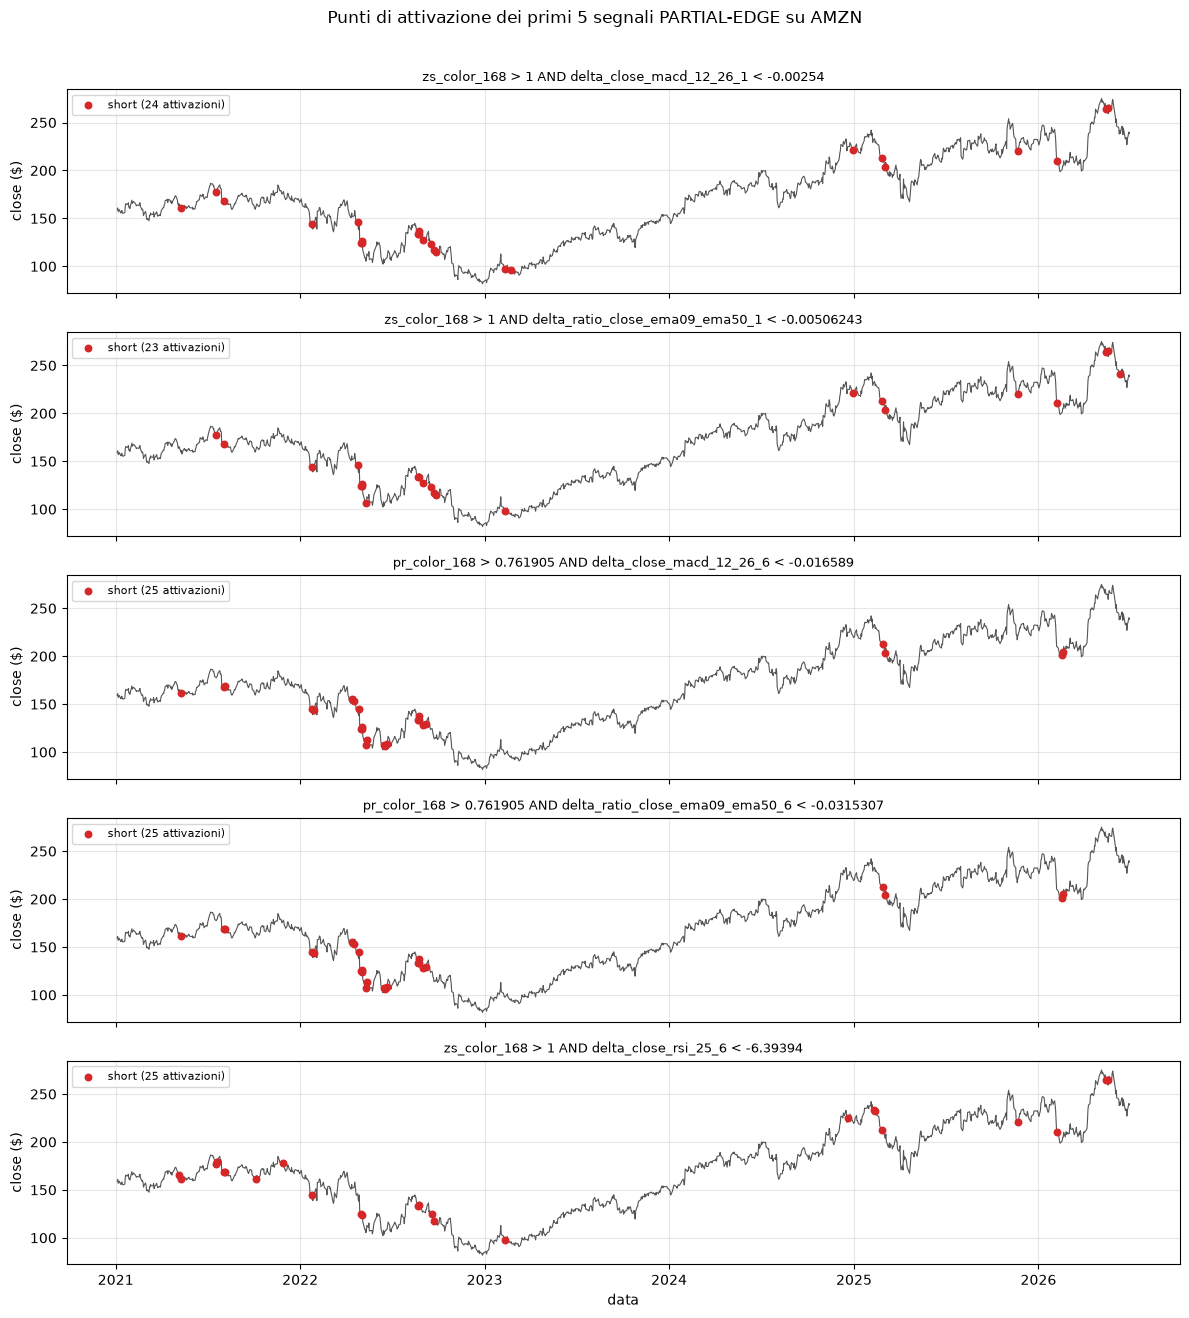

In [14]:
cand_by_id = {c.event_id: c for c in result.candidates}
price = result.enriched.set_index("open_dt")["close"]
top5 = partial_edge[:5]

fig, axes = plt.subplots(len(top5), 1, figsize=(12, 2.6 * len(top5)), sharex=True)
for ax, (cc, r) in zip(axes, top5):
    cand = cand_by_id.get(cc.event_candidate_id)
    ax.plot(price.index, price.values, color="#555", lw=0.8)
    if cand is not None and cand.event_series is not None:
        ev = cand.event_series.reindex(price.index).fillna(0).astype(bool)
        color = "#d62728" if cc.direction == "short" else "#2ca02c"
        ax.scatter(price.index[ev], price.values[ev], color=color, s=22, zorder=5,
                   label=f"{cc.direction} ({int(ev.sum())} attivazioni)")
        ax.legend(loc="upper left", fontsize=8)
    ax.set_title(cc.event_expression, fontsize=9)
    ax.set_ylabel("close ($)")

axes[-1].set_xlabel("data")
fig.suptitle("Punti di attivazione dei primi 5 segnali PARTIAL-EDGE su AMZN", y=1.01)
plt.tight_layout()
plt.show()

## 12 — Confronto con Buy & Hold

Le metriche IS/OOS dicono se una regola è statisticamente robusta, ma non dicono *quanto* renderebbe rispetto alla strategia più semplice possibile: comprare e tenere. Ricostruiamo l'equity curve (capitale composto, partendo da 1×) di ciascuno dei primi 5 segnali con `run_backtest()` usando i parametri validati da M3 (`r.validated_rule.params`), e la confrontiamo con il Buy & Hold di AMZN sullo stesso periodo.

Nota: i segnali trovati sono prevalentemente **short** — non vanno confrontati come "sostituti" del Buy & Hold (long-only), ma come fonte di rendimento *decorrelata*: idealmente guadagnano (o restano piatti) anche quando il prezzo scende, cosa che il Buy & Hold per definizione non può fare.

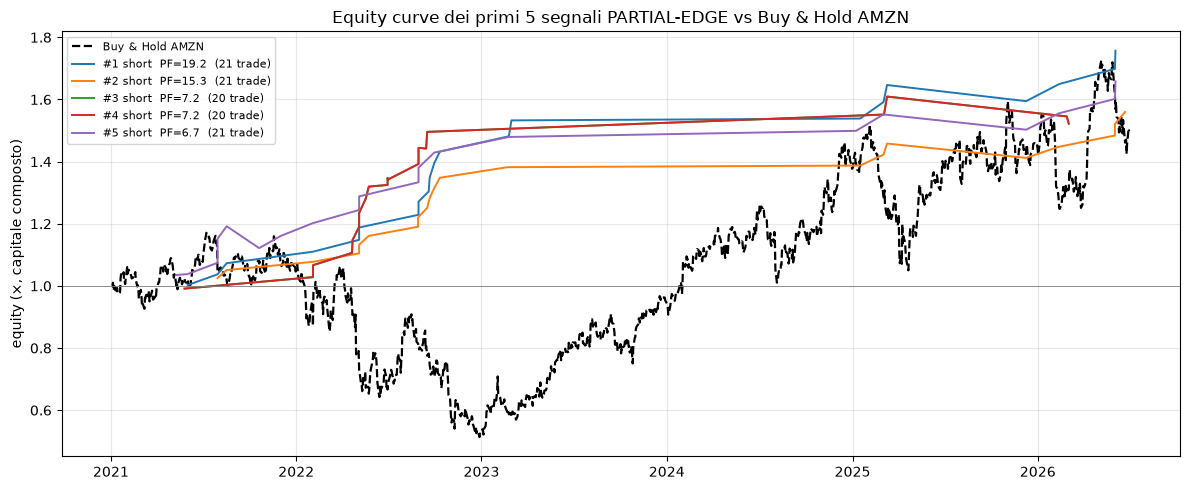

,expression,direction,trades,total return %,max drawdown %
#,,,,,
1,zs_color_168 > 1 AND delta_close_macd_12_26_1 ...,short,21,75.7,-3.2
2,zs_color_168 > 1 AND delta_ratio_close_ema09_e...,short,21,56.0,-3.2
3,pr_color_168 > 0.761905 AND delta_close_macd_1...,short,20,52.2,-5.4
4,pr_color_168 > 0.761905 AND delta_ratio_close_...,short,20,52.2,-5.4
5,zs_color_168 > 1 AND delta_close_rsi_25_6 < -6...,short,21,65.8,-5.9
B&H,Buy & Hold AMZN,long,1,49.8,-56.1


In [15]:
bh_equity = price / price.iloc[0]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(bh_equity.index, bh_equity.values, color="black", lw=1.6, ls="--", label="Buy & Hold AMZN")

summary_rows = []
for i, (cc, r) in enumerate(top5, 1):
    cand = cand_by_id.get(cc.event_candidate_id)
    if cand is None or r.validated_rule is None:
        continue
    frame = result.enriched.copy()
    frame["__chart_signal__"] = cand.event_series.reindex(frame["open_dt"]).fillna(0).values
    _, trades = run_backtest(frame, "__chart_signal__", r.validated_rule.params,
                             timestamp_col="open_dt", return_trades=True)
    if len(trades) == 0:
        continue
    trades = trades.sort_values("exit_dt")
    eq = (1 + trades["net_pct_gain"]).cumprod()
    eq.index = pd.to_datetime(trades["exit_dt"])
    pf = r.in_sample_summary.profit_factor
    pf_label = "∞" if pf >= 999 else f"{pf:.1f}"
    ax.plot(eq.index, eq.values, lw=1.4,
            label=f"#{i} {cc.direction}  PF={pf_label}  ({len(trades)} trade)")
    summary_rows.append({
        "#": i,
        "expression": cc.event_expression,
        "direction": cc.direction,
        "trades": len(trades),
        "total return %": round((eq.iloc[-1] - 1) * 100, 1),
        "max drawdown %": round(((eq / eq.cummax() - 1).min()) * 100, 1),
    })

ax.axhline(1, color="gray", lw=0.6)
ax.set_ylabel("equity (×, capitale composto)")
ax.set_title("Equity curve dei primi 5 segnali PARTIAL-EDGE vs Buy & Hold AMZN")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

bh_total_return = (bh_equity.iloc[-1] - 1) * 100
bh_dd = ((bh_equity / bh_equity.cummax() - 1).min()) * 100
summary_rows.append({"#": "B&H", "expression": "Buy & Hold AMZN", "direction": "long",
                     "trades": 1, "total return %": round(bh_total_return, 1),
                     "max drawdown %": round(bh_dd, 1)})
pd.DataFrame(summary_rows).set_index("#")

## 13 — Interpretazione

### Come leggere i risultati

I segnali con verdetto `PARTIAL-EDGE` e **consistency 100%** (sezione 10) sono i candidati più solidi: profittevoli in ogni split walk-forward, quindi non dipendenti da un singolo periodo fortunato. Il grafico delle attivazioni (sezione 11) mostra *dove* nel tempo scatta ciascuna regola — segnali concentrati in 2-3 cluster temporali sono meno affidabili di segnali distribuiti su tutto il periodo. Il confronto con il Buy & Hold (sezione 12) mostra che i segnali trovati sono prevalentemente **short**: non competono col Buy & Hold come alternativa long, ma come fonte di rendimento decorrelata che può restare piatta o guadagnare durante le correzioni (es. 2022) in cui il Buy & Hold perde valore.

### Pattern ricorrenti su AMZN 1D

Tra i segnali `PARTIAL-EDGE` trovati ricorrono alcuni ingredienti:
- **Momentum di colore delle barre** (`zs_color_*`, `pr_color_*`): conteggio normalizzato di barre rialziste/ribassiste su finestre lunghe (48-168 barre) — cattura fasi di pressione direzionale sostenuta.
- **Variazioni MACD** (`delta_close_macd_12_26_*`): cali/risalite rapide della linea MACD normalizzata (sezione 3) — il MACD qui è espresso come frazione del prezzo, non in unità di prezzo grezze, proprio per essere riconosciuto da `forge()` indipendentemente dal livello di prezzo dell'asset.
- **Divergenze RSI** (`delta_close_rsi_*`, `close_rsi_25`): spike o cali rapidi del RSI a breve termine in contesto di RSI a lungo termine già esteso — tipico segnale di esaurimento del movimento.

Tutti questi pattern emergono **automaticamente** da `forge()` a partire dagli indicatori grezzi configurati in sezione 3 — nessuna di queste combinazioni è stata scelta a mano.

### Note sul verdetto PARTIAL-EDGE
- `PARTIAL-EDGE` ≠ segnale invalido: indica che l'edge c'è ma non ha ancora la significatività statistica piena di un `EDGE`.
- Passo consigliato: paper trading 3-6 mesi, poi rivalutare se il PF OOS live resta sopra soglia.
- Monitorare il **decay** del PF: se il PF OOS scende sotto 1.5 in live, il regime di mercato è probabilmente cambiato.

---

## Appendice — Struttura di `ForgeResult`

```python
result = forge(kpi, ...)

result.enriched          # KPI Table dopo MarketContext (+ colonna 'regime')
result.candidates        # List[EventCandidate]  — tutti i candidati M1
result.contracts         # List[AlphaContract]   — tutti i contratti M2
result.promoted          # List[AlphaContract]   — solo quelli promossi
result.rule_responses    # List[Tuple[AlphaContract, RuleDiscoveryResponse]]

# Per ogni risposta M3:
cc, r = result.rule_responses[0]
r.verdict                       # "EDGE" / "PARTIAL-EDGE" / "NON-EDGE"
r.in_sample_summary.profit_factor
r.in_sample_summary.win_rate_pct  # fraction [0, 1]
r.in_sample_summary.total_trades
r.in_sample_summary.expectancy
r.walk_forward.oos_summary        # BacktestSummary aggregato OOS
r.walk_forward.consistency        # frazione split profittevoli
r.walk_forward.splits             # List[WalkForwardSplit]
r.statistical_validation          # DSharpe, t-stat, temporal_stability

# Dal contratto M2:
cc.event_expression               # regola leggibile
cc.direction                      # "long" / "short"
cc.derived_target.holding_period_h
cc.derived_target.sell_pct
cc.event_stats.lift
cc.event_stats.n_activations
```